In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile
import urllib.request

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
# Model Definitions: Generator
class GeneratorTeach(nn.Module):
    def __init__(self, channels_noise, channels_img, features_g, num_classes, img_size, embed_size):
        super(GeneratorTeach, self).__init__()
        self.img_size = img_size
        self.embed = nn.Embedding(num_classes, embed_size)
        
        self.net = nn.Sequential(
            # Input: N x (NOISE_DIM + EMBED_SIZE) x 1 x 1
            self._block(channels_noise + embed_size, features_g * 16, 4, 1, 0),
            self._block(features_g * 16, features_g * 8, 4, 2, 1),
            self._block(features_g * 8, features_g * 4, 4, 2, 1),
            self._block(features_g * 4, features_g * 2, 4, 2, 1),
            nn.ConvTranspose2d(features_g * 2, channels_img, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x, labels):
        # Latent vector z: N x NOISE_DIM x 1 x 1
        embedding = self.embed(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([x, embedding], dim=1)
        return self.net(x)
    

# Model Definitions: Discriminator
class DiscriminatorTeach(nn.Module):
    def __init__(self, channels_img, features_d, num_classes, img_size):
        super(DiscriminatorTeach, self).__init__()
        self.img_size = img_size
        self.embed = nn.Embedding(num_classes, img_size * img_size)
        
        self.disc = nn.Sequential(
            # Input: N x (channels_img + 1) x 64 x 64
            nn.Conv2d(channels_img + 1, features_d, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1),
            self._block(features_d * 2, features_d * 4, 4, 2, 1),
            self._block(features_d * 4, features_d * 8, 4, 2, 1),
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=2, padding=0),
            # Output: N x 1 x 1 x 1
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.InstanceNorm2d(out_channels, affine=True), # LayerNorm/InstanceNorm is often better for WGAN/cGAN
            nn.LeakyReLU(0.2),
        )

    def forward(self, x, labels):
        embedding = self.embed(labels).view(labels.shape[0], 1, self.img_size, self.img_size)
        x = torch.cat([x, embedding], dim=1)
        return self.disc(x)


# Simplified DCGAN for Pokemon (Unconditional)
class GeneratorPoke(nn.Module):
    def __init__(self, channels_noise, channels_img, features_g):
        super(GeneratorPoke, self).__init__()
        self.net = nn.Sequential(
            self._block(channels_noise, features_g * 16, 4, 1, 0),
            self._block(features_g * 16, features_g * 8, 4, 2, 1),
            self._block(features_g * 8, features_g * 4, 4, 2, 1),
            self._block(features_g * 4, features_g * 2, 4, 2, 1),
            nn.ConvTranspose2d(features_g * 2, channels_img, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )
    
    def forward(self, x):
        return self.net(x)

class DiscriminatorPoke(nn.Module):
    def __init__(self, channels_img, features_d):
        super(DiscriminatorPoke, self).__init__()
        self.disc = nn.Sequential(
            nn.Conv2d(channels_img, features_d, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1),
            self._block(features_d * 2, features_d * 4, 4, 2, 1),
            self._block(features_d * 4, features_d * 8, 4, 2, 1),
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=2, padding=0),
            nn.Sigmoid(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x):
        return self.disc(x)

--- 
## Part 1: Conditional GAN (cGAN) for MNIST

We will generate handwritten digits conditioned on their class label.

In [2]:
# Hyperparameters
LEARNING_RATE = 2e-4
BATCH_SIZE = 128
IMAGE_SIZE = 64
CHANNELS_IMG = 1
NOISE_DIM = 100
NUM_EPOCHS = 5
FEATURES_D = 64
FEATURES_G = 64
NUM_CLASSES = 10
EMBED_SIZE = 100

In [3]:
# Data Loading
transforms_mnist = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5 for _ in range(CHANNELS_IMG)], [0.5 for _ in range(CHANNELS_IMG)]),
])

dataset_mnist = datasets.MNIST(root="dataset/", train=True, transform=transforms_mnist, download=True)
loader_mnist = DataLoader(dataset_mnist, batch_size=BATCH_SIZE, shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 24.0MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 24.0MB/s]


Extracting dataset/MNIST/raw/train-images-idx3-ubyte.gz to dataset/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 718kB/s]

Extracting dataset/MNIST/raw/train-labels-idx1-ubyte.gz to dataset/MNIST/raw



Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 6.74MB/s]



Extracting dataset/MNIST/raw/t10k-images-idx3-ubyte.gz to dataset/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.38MB/s]

Extracting dataset/MNIST/raw/t10k-labels-idx1-ubyte.gz to dataset/MNIST/raw



In [6]:
# Initialization
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

gen = Generator(NOISE_DIM, CHANNELS_IMG, FEATURES_G, NUM_CLASSES, IMAGE_SIZE, EMBED_SIZE).to(device)
disc = Discriminator(CHANNELS_IMG, FEATURES_D, NUM_CLASSES, IMAGE_SIZE).to(device)
initialize_weights(gen)
initialize_weights(disc)

opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

Starting Training...
Epoch [0/5] Batch 0/469 	 Loss D: 0.8271, Loss G: 7.2722
Epoch [0/5] Batch 0/469 	 Loss D: 0.8271, Loss G: 7.2722
Epoch [0/5] Batch 100/469 	 Loss D: 0.4011, Loss G: 7.8864
Epoch [0/5] Batch 100/469 	 Loss D: 0.4011, Loss G: 7.8864
Epoch [0/5] Batch 200/469 	 Loss D: 0.3028, Loss G: 3.6686
Epoch [0/5] Batch 200/469 	 Loss D: 0.3028, Loss G: 3.6686
Epoch [0/5] Batch 300/469 	 Loss D: 0.3298, Loss G: 2.6878
Epoch [0/5] Batch 300/469 	 Loss D: 0.3298, Loss G: 2.6878
Epoch [0/5] Batch 400/469 	 Loss D: 0.4200, Loss G: 3.3388
Epoch [0/5] Batch 400/469 	 Loss D: 0.4200, Loss G: 3.3388
Epoch [1/5] Batch 0/469 	 Loss D: 0.3237, Loss G: 3.2502
Epoch [1/5] Batch 0/469 	 Loss D: 0.3237, Loss G: 3.2502
Epoch [1/5] Batch 100/469 	 Loss D: 0.3942, Loss G: 3.7512
Epoch [1/5] Batch 100/469 	 Loss D: 0.3942, Loss G: 3.7512
Epoch [1/5] Batch 200/469 	 Loss D: 0.4091, Loss G: 2.0785
Epoch [1/5] Batch 200/469 	 Loss D: 0.4091, Loss G: 2.0785
Epoch [1/5] Batch 300/469 	 Loss D: 0.3992,

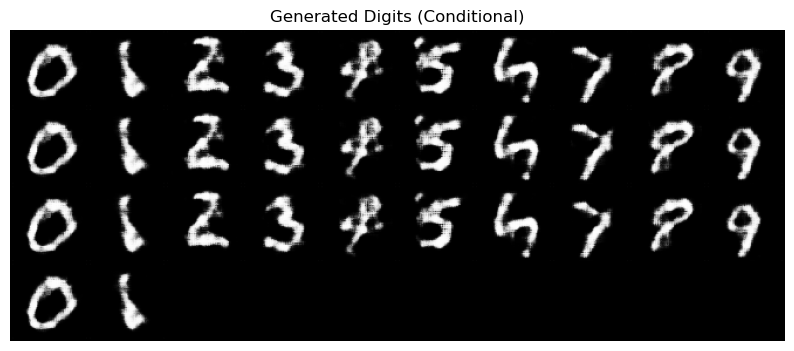

In [ ]:
# Training Loop (MNIST)
fixed_noise = torch.randn(32, NOISE_DIM, 1, 1).to(device)
fixed_labels = torch.cat([torch.arange(10) for _ in range(3)] + [torch.tensor([0, 1])]).to(device) # 32 labels
fixed_labels = fixed_labels[:32]

print("Starting Training...")
gen.train()
disc.train()

for epoch in range(NUM_EPOCHS):
    for batch_idx, (real, labels) in enumerate(loader_mnist):
        real = real.to(device)
        labels = labels.to(device)
        batch_size = real.shape[0]

        ### Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        noise = torch.randn(batch_size, NOISE_DIM, 1, 1).to(device)
        fake = gen(noise, labels)
        
        disc_real = disc(real, labels).reshape(-1)
        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real) * 0.9) # Label smoothing
        
        disc_fake = disc(fake.detach(), labels).reshape(-1)
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
        
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        ### Train Generator: max log(D(G(z)))
        output = disc(fake, labels).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))
        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch}/{NUM_EPOCHS}] Batch {batch_idx}/{len(loader_mnist)} \t Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

# Visualization
with torch.no_grad():
    fake = gen(fixed_noise, fixed_labels)
    img_grid = torchvision.utils.make_grid(fake, normalize=True, nrow=10)
    plt.figure(figsize=(10, 10))
    plt.imshow(img_grid.permute(1, 2, 0).cpu().numpy())
    plt.title("Generated Digits (Conditional)")
    plt.axis("off")

--- 
## Part 2: Pokemon GAN

We will use a DCGAN to generate Pokemon characters.

In [8]:
# Download Pokemon Data
data_url = "http://d2l-data.s3-accelerate.amazonaws.com/pokemon.zip"
data_dir = "./pokemon_data"
zip_path = os.path.join(data_dir, "pokemon.zip")

if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    print("Downloading Pokemon dataset...")
    urllib.request.urlretrieve(data_url, zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Done!")
else:
    print("Pokemon dataset already exists.")

Extracting...
Extracting...
Done!
Done!


In [9]:
# Pokemon Data Loading
BATCH_SIZE_POKE = 64
IMAGE_SIZE_POKE = 64
CHANNELS_POKE = 3

transforms_poke = transforms.Compose([
    transforms.Resize(IMAGE_SIZE_POKE),
    transforms.CenterCrop(IMAGE_SIZE_POKE),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# The extracted folder structure is usually pokemon_data/pokemon/...
# ImageFolder requires a root folder with subfolders as classes. 
# If the zip extracts images directly into 'pokemon', we point to the parent 'pokemon_data'
dataset_poke = datasets.ImageFolder(root=data_dir, transform=transforms_poke)
loader_poke = DataLoader(dataset_poke, batch_size=BATCH_SIZE_POKE, shuffle=True)

Starting Pokemon Training...
Epoch [0/10] Batch 0/635 	 Loss D: 0.6989, Loss G: 0.7820
Epoch [0/10] Batch 0/635 	 Loss D: 0.6989, Loss G: 0.7820


/Users/marston.ward/miniforge3/envs/pytorch/lib/python3.12/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [0/10] Batch 10/635 	 Loss D: 0.4283, Loss G: 1.3203
Epoch [0/10] Batch 20/635 	 Loss D: 0.2896, Loss G: 1.7850
Epoch [0/10] Batch 20/635 	 Loss D: 0.2896, Loss G: 1.7850
Epoch [0/10] Batch 30/635 	 Loss D: 0.2340, Loss G: 2.1715
Epoch [0/10] Batch 30/635 	 Loss D: 0.2340, Loss G: 2.1715
Epoch [0/10] Batch 40/635 	 Loss D: 0.2085, Loss G: 2.5248
Epoch [0/10] Batch 40/635 	 Loss D: 0.2085, Loss G: 2.5248
Epoch [0/10] Batch 50/635 	 Loss D: 0.1951, Loss G: 2.8173
Epoch [0/10] Batch 50/635 	 Loss D: 0.1951, Loss G: 2.8173
Epoch [0/10] Batch 60/635 	 Loss D: 0.1877, Loss G: 3.0681
Epoch [0/10] Batch 60/635 	 Loss D: 0.1877, Loss G: 3.0681
Epoch [0/10] Batch 70/635 	 Loss D: 0.1829, Loss G: 3.3231
Epoch [0/10] Batch 70/635 	 Loss D: 0.1829, Loss G: 3.3231
Epoch [0/10] Batch 80/635 	 Loss D: 0.1780, Loss G: 3.5658
Epoch [0/10] Batch 80/635 	 Loss D: 0.1780, Loss G: 3.5658
Epoch [0/10] Batch 90/635 	 Loss D: 0.1752, Loss G: 3.7586
Epoch [0/10] Batch 90/635 	 Loss D: 0.1752, Loss G: 3.75

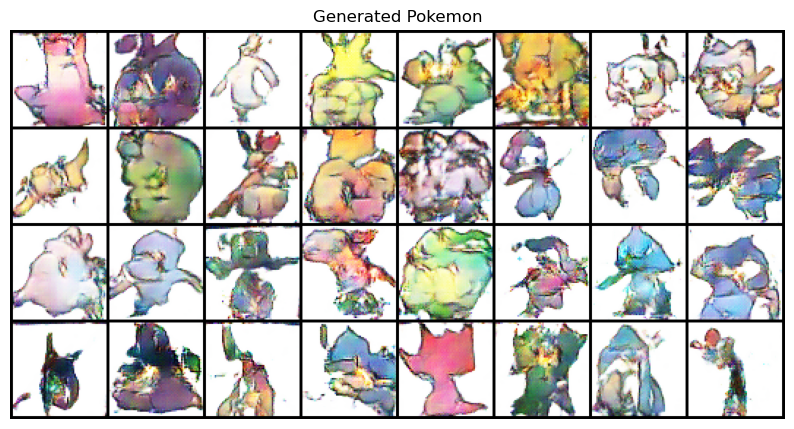

In [ ]:
# Setup Pokemon Training
gen_poke = GeneratorPoke(NOISE_DIM, CHANNELS_POKE, FEATURES_G).to(device)
disc_poke = DiscriminatorPoke(CHANNELS_POKE, FEATURES_D).to(device)
initialize_weights(gen_poke)
initialize_weights(disc_poke)

opt_gen_poke = optim.Adam(gen_poke.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
opt_disc_poke = optim.Adam(disc_poke.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
criterion_poke = nn.BCELoss()

fixed_noise_poke = torch.randn(32, NOISE_DIM, 1, 1).to(device)

print("Starting Pokemon Training...")
gen_poke.train()
disc_poke.train()

for epoch in range(NUM_EPOCHS + 5): # Train a bit longer for Pokemon
    for batch_idx, (real, _) in enumerate(loader_poke):
        real = real.to(device)
        batch_size = real.shape[0]

        ### Train Discriminator
        noise = torch.randn(batch_size, NOISE_DIM, 1, 1).to(device)
        fake = gen_poke(noise)
        
        disc_real = disc_poke(real).reshape(-1)
        loss_disc_real = criterion_poke(disc_real, torch.ones_like(disc_real) * 0.9)
        
        disc_fake = disc_poke(fake.detach()).reshape(-1)
        loss_disc_fake = criterion_poke(disc_fake, torch.zeros_like(disc_fake))
        
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        disc_poke.zero_grad()
        loss_disc.backward()
        opt_disc_poke.step()

        ### Train Generator
        output = disc_poke(fake).reshape(-1)
        loss_gen = criterion_poke(output, torch.ones_like(output))
        gen_poke.zero_grad()
        loss_gen.backward()
        opt_gen_poke.step()

        if batch_idx % 10 == 0:
            print(f"Epoch [{epoch}/{NUM_EPOCHS+5}] Batch {batch_idx}/{len(loader_poke)} \t Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

# Visualization
with torch.no_grad():
    fake = gen_poke(fixed_noise_poke)
    img_grid = torchvision.utils.make_grid(fake, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(img_grid.permute(1, 2, 0).cpu().numpy())
    plt.title("Generated Pokemon")
    plt.axis("off")